# 08 — Online Experimentation: Network Effects, Switchback, and Variance Reduction
**References:** Kohavi et al. (2020) · Bojinov & Shephard (2019) · Ugander et al. (2013) · Deng et al. (2013)

## Narrative thread
```
Standard A/B -> Network effects (interference) -> Cluster randomization -> Switchback -> CUPED -> Interleaving
```

## Why standard A/B tests break in online platforms

Standard A/B testing assumes the **Stable Unit Treatment Value Assumption (SUTVA)**:
$$Y_i(d_1, \ldots, d_n) = Y_i(d_i)$$

My outcome depends only on my treatment, not others'. SUTVA fails when:

1. **Network effects (interference):** social platforms, marketplaces, messaging apps. If I'm on treatment, my friend (control) also changes behavior.
2. **Two-sided markets:** changing prices/supply for treatment users affects availability for control users (Lyft, Airbnb, Instacart).
3. **Novelty/primacy effects:** users react to novelty, not the steady-state treatment.

## Solutions

| Problem | Solution | Tradeoff |
|---|---|---|
| Network effects | Cluster randomization | Lower power (fewer clusters than users) |
| Marketplace interference | Switchback / time-based | Requires stationarity, autocorrelation |
| Novelty effects | Holdout / long-run exposure | Slower, more expensive |
| Low power | CUPED (variance reduction) | Requires pre-experiment data |
| Ranking experiments | Interleaving | Faster, but only relative comparison |

## Cluster randomization

Randomize **clusters** (groups of interconnected users) instead of individual users.

- Reduces interference: users in the same cluster see the same treatment
- **Design effect:** $\text{DEFF} = 1 + (m-1)\rho$ where $m$ = cluster size, $\rho$ = intra-cluster correlation (ICC)
- Required sample: $n_{cluster} = n_{simple} \times \text{DEFF}$
- A high ICC (users within cluster very similar) makes cluster RCT expensive

## Switchback design

Alternate treatments over **time periods** rather than users. Each time period is a "unit."
Used when users are hard to randomize (or all users must get same experience, e.g., marketplaces).

**Key assumption:** carryover effects decay quickly enough between periods.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from itertools import product

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

Network effects: bias from SUTVA violation
  True direct effect: 3.00
  Naive ATE estimate: 4.1503  (biased due to spillover into control)

Cluster RCT design effect:
  ICC=0.05  cluster_size=20
  DEFF = 1 + (20-1)*0.05 = 1.95
  Need 2.0x more observations vs individual randomization
  Cluster RCT ATE=2.6342  SE=0.4414

Switchback design:
  True effect: 2.5  Naive: 2.5170  Regression-adjusted: 2.6054


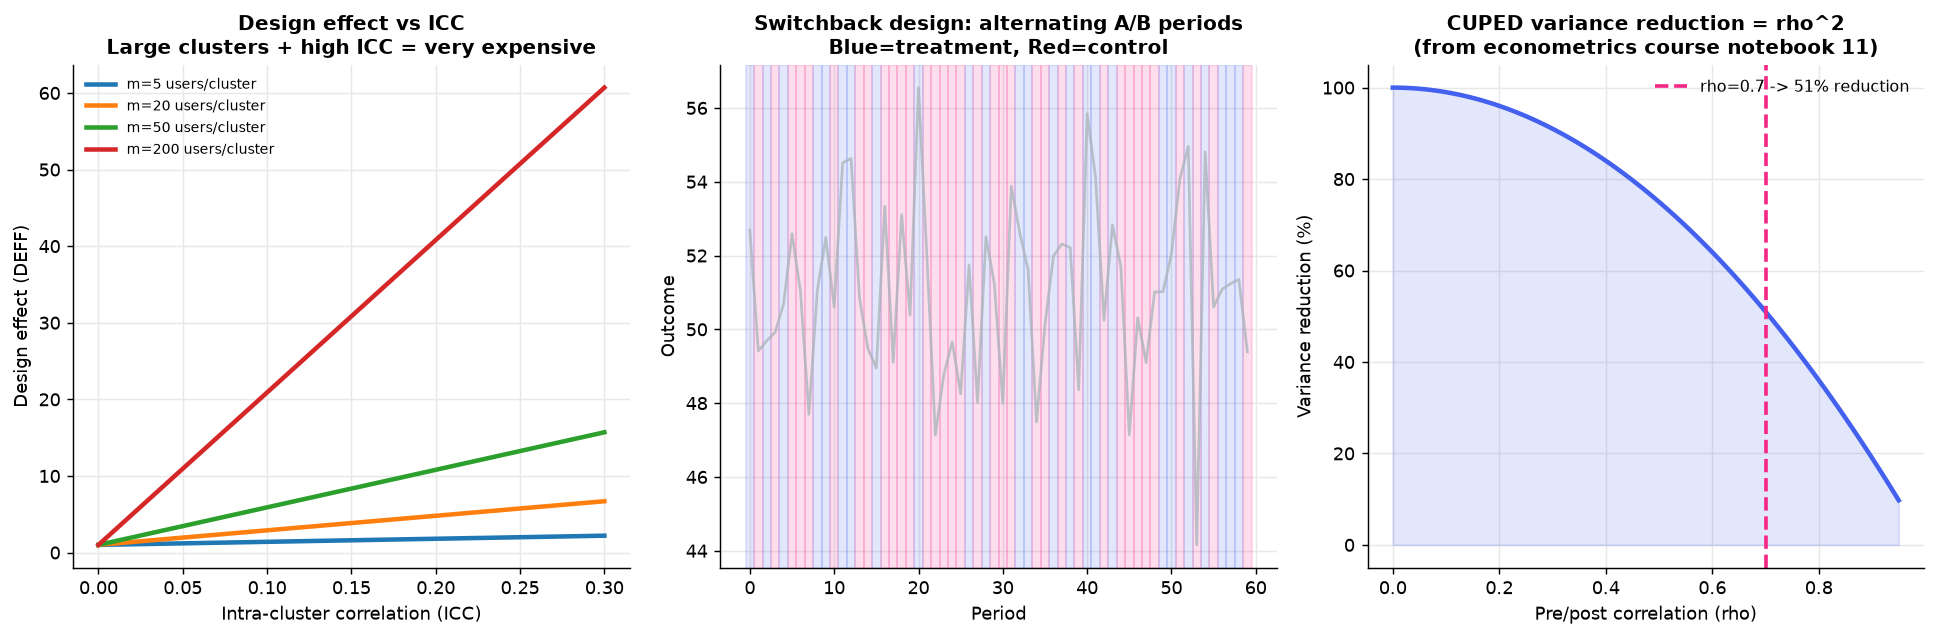

In [2]:
# ── Network effects: bias from SUTVA violation ───────────────────────────
np.random.seed(42)

n = 2000
# Social network: friend connections
n_friends = np.random.poisson(5, n)   # avg 5 friends per user

# True parameters
direct_effect   = 3.0   # effect on treated user
spillover_coeff = 0.5   # fraction of friends treated that spills over

# Naive A/B: individual-level randomization
D_naive = np.random.binomial(1, 0.5, n).astype(float)

# For each user, compute fraction of friends treated
# (simplified: treat fraction of friends proportional to avg)
frac_friends_treated = np.random.beta(D_naive * 3 + 0.5, (1-D_naive) * 3 + 0.5)

# Potential outcomes with spillover
Y0 = 10 + spillover_coeff * frac_friends_treated * direct_effect + np.random.normal(0, 2, n)
Y1 = Y0 + direct_effect
Y_obs = np.where(D_naive==1, Y1, Y0)

# Naive estimate
ate_naive_net = Y_obs[D_naive==1].mean() - Y_obs[D_naive==0].mean()
print(f'Network effects: bias from SUTVA violation')
print(f'  True direct effect: {direct_effect:.2f}')
print(f'  Naive ATE estimate: {ate_naive_net:.4f}  (biased due to spillover into control)')

# ── Cluster randomization ─────────────────────────────────────────────────
n_clusters = 100; cluster_size = 20
icc = 0.05   # intra-cluster correlation
deff = 1 + (cluster_size - 1) * icc
print(f'\nCluster RCT design effect:')
print(f'  ICC={icc}  cluster_size={cluster_size}')
print(f'  DEFF = 1 + ({cluster_size}-1)*{icc} = {deff:.2f}')
print(f'  Need {deff:.1f}x more observations vs individual randomization')

# Simulate cluster RCT
cluster_effects = np.random.normal(0, 2, n_clusters)   # large between-cluster var
cluster_assign  = np.random.binomial(1, 0.5, n_clusters)

records = []
for c in range(n_clusters):
    for _ in range(cluster_size):
        y = 10 + cluster_effects[c] + direct_effect*cluster_assign[c] + np.random.normal(0, 1)
        records.append({'cluster': c, 'D': cluster_assign[c], 'y': y})
df_cluster = pd.DataFrame(records)

# Cluster-robust SE: aggregate to cluster-level means first
cluster_means = df_cluster.groupby('cluster').agg({'D':'first','y':'mean'}).reset_index()
mod_cluster = sm.OLS(cluster_means['y'], sm.add_constant(cluster_means['D'])).fit(
    cov_type='HC3')
print(f'  Cluster RCT ATE={mod_cluster.params.iloc[1]:.4f}  SE={mod_cluster.bse.iloc[1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# DEFF vs ICC curve
icc_vals = np.linspace(0, 0.3, 100)
for m in [5, 20, 50, 200]:
    deff_curve = 1 + (m-1)*icc_vals
    axes[0].plot(icc_vals, deff_curve, lw=2.5, label=f'm={m} users/cluster')
axes[0].set_xlabel('Intra-cluster correlation (ICC)')
axes[0].set_ylabel('Design effect (DEFF)')
axes[0].set_title('Design effect vs ICC\nLarge clusters + high ICC = very expensive')
axes[0].legend(fontsize=8)

# ── Switchback design ─────────────────────────────────────────────────────
T_periods = 60; period_length = 30   # 60 periods, 30 obs each
true_eff_sw = 2.5; carryover = 0.3

periods = np.arange(T_periods)
# Random sequence of A/B periods
D_period = np.array([np.random.binomial(1,0.5) for _ in range(T_periods)])

y_periods = []
for t in range(T_periods):
    base = 50.0
    direct = true_eff_sw * D_period[t]
    carry  = carryover * true_eff_sw * D_period[t-1] if t > 0 else 0
    y_t = base + direct + carry + np.random.normal(0, 2)
    y_periods.append(y_t)
y_periods = np.array(y_periods)

# Naive estimate (ignores carryover)
ate_sw_naive = y_periods[D_period==1].mean() - y_periods[D_period==0].mean()
# Better: include lagged D in regression
X_sw = sm.add_constant(np.column_stack([D_period[1:],D_period[:-1]]))
mod_sw = sm.OLS(y_periods[1:], X_sw).fit()
print(f'\nSwitchback design:')
print(f'  True effect: {true_eff_sw}  Naive: {ate_sw_naive:.4f}  Regression-adjusted: {mod_sw.params[1]:.4f}')

axes[1].plot(periods, y_periods, color='#adb5bd', lw=1.5, alpha=0.8)
for t in range(T_periods):
    color = '#4361ee' if D_period[t]==1 else '#f72585'
    axes[1].axvspan(t-0.5, t+0.5, alpha=0.15, color=color)
axes[1].set_xlabel('Period'); axes[1].set_ylabel('Outcome')
axes[1].set_title(f'Switchback design: alternating A/B periods\nBlue=treatment, Red=control')

# ── Variance reduction summary ─────────────────────────────────────────────
rho_vals = np.linspace(0, 0.95, 100)
var_reduction = 1 - rho_vals**2
axes[2].plot(rho_vals, var_reduction*100, color='#4361ee', lw=2.5)
axes[2].fill_between(rho_vals, 0, var_reduction*100, alpha=0.15, color='#4361ee')
axes[2].axvline(0.7, color='#f72585', lw=2, linestyle='--', label='rho=0.7 -> 51% reduction')
axes[2].set_xlabel('Pre/post correlation (rho)')
axes[2].set_ylabel('Variance reduction (%)')
axes[2].set_title('CUPED variance reduction = rho^2\n(from econometrics course notebook 11)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()